# Batch Evaluation — Unseen Books
Loads the trained classifiers and evaluates them against books from Project Gutenberg that were **not** used in training.

**Run order:** `BOW.ipynb` → `Book partitioner.ipynb` → `Genre classifier.ipynb` → **this notebook**

**Required files (produced by prior notebooks):**
- `FeatureTrainingData/vectorizer.pkl`
- `model_logistic_regression.pkl`
- `model_svm.pkl`
- `model_random_forest.pkl`
- `model_naive_bayes.pkl`
- `model_xgboost.pkl`
- `model_distilbert/`

Books are downloaded automatically from Project Gutenberg and cached in `TestBooks/`.

In [14]:
import re
import random
import joblib
import requests
import time
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
)
import matplotlib.pyplot as plt

## Configuration
The `GENRE_BOOKS` dict maps each genre to a list of `(gutenberg_id, title)` pairs.
All books were **not** used in training. Verify or find additional IDs at https://www.gutenberg.org/

In [15]:
PARTITION_SIZE = 400
NUM_PARTITIONS = 200
RANDOM_STATE   = 42
GENRES = ['biography', 'fantasy', 'horror', 'romance', 'sci-fi']

GENRE_BOOKS = {
    'biography': [
        (2376,  'Up from Slavery - Booker T Washington'),
        (2044,  'The Education of Henry Adams'),
        (10378, 'Autobiography - John Stuart Mill'),
        (3913,  'Confessions - Jean-Jacques Rousseau'),
        (4028,  'Autobiography of Benvenuto Cellini'),
        (5140,  'An Autobiography - Anthony Trollope'),
        (11030, 'Incidents in the Life of a Slave Girl'),
        (654,   'Grace Abounding - John Bunyan'),
        (4367,  'Personal Memoirs of Ulysses S Grant'),
        (14214, 'Theodore Roosevelt An Autobiography'),
        (20455, 'Geronimos Story of His Life'),
        (15399, 'The Interesting Narrative - Olaudah Equiano'),
        (16120, 'Narrative of Sojourner Truth'),
        (3296,  'Confessions of Saint Augustine'),
        (14026, 'Struggles and Triumphs - PT Barnum'),
        (9836,  'My Bondage and My Freedom - Frederick Douglass'),
        (4200,  'Diary of Samuel Pepys Vol 1'),
        (1325,  'Twenty Years at Hull-House - Jane Addams'),
        (932,   'Narrative of William Wells Brown'),
        (2805,  'My Life on the Plains - George Custer'),
    ],
    'fantasy': [
        (34,    'The Princess and the Goblin - MacDonald'),
        (225,   'At the Back of the North Wind - MacDonald'),
        (325,   'Phantastes - George MacDonald'),
        (503,   'The Blue Fairy Book - Andrew Lang'),
        (540,   'The Red Fairy Book - Andrew Lang'),
        (574,   'The Well at the Worlds End - William Morris'),
        (2166,  'King Solomons Mines - H Rider Haggard'),
        (3155,  'She - H Rider Haggard'),
        (54,    'The Marvelous Land of Oz - L Frank Baum'),
        (10662, 'The Night Land - WH Hodgson'),
        (765,   'The Moon Pool - A Merritt'),
        (7477,  'The Book of Wonder - Lord Dunsany'),
        (14082, 'The King of Elflands Daughter - Lord Dunsany'),
        (16,    'Peter Pan - JM Barrie'),
        (5,     'Andersens Fairy Tales'),
        (33361, 'Ozma of Oz - L Frank Baum'),
        (150,   'The Violet Fairy Book - Andrew Lang'),
        (1332,  'The Princess and the Curdie - George MacDonald'),
        (5317,  'The Enchanted Island of Yew - L Frank Baum'),
        (151,   'The Yellow Fairy Book - Andrew Lang'),
    ],
    'horror': [
        (174,   'The Picture of Dorian Gray - Oscar Wilde'),
        (389,   'The Great God Pan - Arthur Machen'),
        (8984,  'The House on the Borderland - WH Hodgson'),
        (8486,  'Ghost Stories of an Antiquary - MR James'),
        (4366,  'Can Such Things Be - Ambrose Bierce'),
        (10007, 'Carmilla - Sheridan Le Fanu'),
        (6581,  'The Jewel of Seven Stars - Bram Stoker'),
        (595,   'The Monk - MG Lewis'),
        (3268,  'The Mysteries of Udolpho - Ann Radcliffe'),
        (696,   'The Castle of Otranto - Horace Walpole'),
        (2852,  'The Hound of the Baskervilles - Conan Doyle'),
        (583,   'The Woman in White - Wilkie Collins'),
        (11438, 'The Empty House - Algernon Blackwood'),
        (1155,  'In a Glass Darkly - Sheridan Le Fanu'),
        (5765,  'Uncle Silas - Sheridan Le Fanu'),
        (208,   'The Turn of the Screw - Henry James'),
        (1413,  'The Beetle - Richard Marsh'),
        (9006,  'The Willows - Algernon Blackwood'),
        (175,   'The Phantom of the Opera - Gaston Leroux'),
        (13618, 'The Terror - Arthur Machen'),
    ],
    'romance': [
        (158,   'Emma - Jane Austen'),
        (105,   'Persuasion - Jane Austen'),
        (141,   'Mansfield Park - Jane Austen'),
        (121,   'Northanger Abbey - Jane Austen'),
        (4276,  'North and South - Elizabeth Gaskell'),
        (4274,  'Wives and Daughters - Elizabeth Gaskell'),
        (107,   'Far from the Madding Crowd - Thomas Hardy'),
        (122,   'The Return of the Native - Thomas Hardy'),
        (145,   'Middlemarch - George Eliot'),
        (6688,  'The Mill on the Floss - George Eliot'),
        (599,   'Vanity Fair - WM Thackeray'),
        (2833,  'The Portrait of a Lady - Henry James'),
        (541,   'The Age of Innocence - Edith Wharton'),
        (514,   'Little Women - Louisa May Alcott'),
        (160,   'The Awakening - Kate Chopin'),
        (1023,  'Tess of the dUrbervilles - Thomas Hardy'),
        (153,   'Jude the Obscure - Thomas Hardy'),
        (969,   'The Tenant of Wildfell Hall - Anne Bronte'),
        (2993,  'Agnes Grey - Anne Bronte'),
        (1232,  'Shirley - Charlotte Bronte'),
    ],
    'sci-fi': [
        (5230,  'The Invisible Man - HG Wells'),
        (159,   'The Island of Doctor Moreau - HG Wells'),
        (1013,  'The First Men in the Moon - HG Wells'),
        (18857, 'Journey to the Center of the Earth - Jules Verne'),
        (83,    'From the Earth to the Moon - Jules Verne'),
        (62,    'A Princess of Mars - Edgar Rice Burroughs'),
        (64,    'The Gods of Mars - Edgar Rice Burroughs'),
        (68,    'The Warlord of Mars - Edgar Rice Burroughs'),
        (545,   'At the Earths Core - Edgar Rice Burroughs'),
        (605,   'Pellucidar - Edgar Rice Burroughs'),
        (20869, 'The Skylark of Space - EE Doc Smith'),
        (19141, 'Edisons Conquest of Mars - Garrett Serviss'),
        (624,   'Looking Backward - Edward Bellamy'),
        (10032, 'The Girl in the Golden Atom - Ray Cummings'),
        (201,   'Flatland - Edwin Abbott'),
        (18,    'A Connecticut Yankee in King Arthurs Court'),
        (9741,  'A Honeymoon in Space - George Griffith'),
        (1581,  'When the Sleeper Wakes - HG Wells'),
        (1904,  'In the Days of the Comet - HG Wells'),
        (2488,  'The Mysterious Island - Jules Verne'),
    ],
}

## Load Saved Models

In [16]:
from xgb_wrapper import XGBStringClassifier      # needed to deserialise model_xgboost.pkl
from bert_wrapper import DistilBertGenreClassifier

vec      = joblib.load('FeatureTrainingData/vectorizer.pkl')
lr       = joblib.load('models/model_logistic_regression.pkl')
svm      = joblib.load('models/model_svm.pkl')
rf       = joblib.load('models/model_random_forest.pkl')
nb       = joblib.load('models/model_naive_bayes.pkl')
xgb_clf  = joblib.load('models/model_xgboost.pkl')
bert_clf = DistilBertGenreClassifier('models/model_distilbert')

print(f'Vectorizer vocabulary size : {len(vec.vocabulary_)} words')
print('Models loaded: Logistic Regression, SVM, Random Forest, Naive Bayes, XGBoost, DistilBERT')

Vectorizer vocabulary size : 1109 words
Models loaded: Logistic Regression, SVM, Random Forest, Naive Bayes, XGBoost, DistilBERT


## Download Books from Project Gutenberg
Books are downloaded once and cached in `TestBooks/<genre>/`. Re-running this cell skips already-downloaded files.

Three URL patterns are tried per book to maximise success. A 1-second delay between requests is polite to Gutenberg's servers.

In [17]:
DOWNLOAD_DIR = Path('UnknownBooks')
DOWNLOAD_DIR.mkdir(exist_ok=True)

HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; book-genre-classifier-research)'}

def _fetch(book_id):
    for url in [
        f'https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt',
        f'https://www.gutenberg.org/files/{book_id}/{book_id}-0.txt',
        f'https://www.gutenberg.org/files/{book_id}/{book_id}.txt',
    ]:
        try:
            r = requests.get(url, headers=HEADERS, timeout=30)
            if r.status_code == 200:
                return r.content
        except requests.RequestException:
            continue
    return None

downloaded = {genre: [] for genre in GENRES}
failed     = []

print('Downloading books from Project Gutenberg...')
print('Already-downloaded books are skipped.\n')

for genre, books in GENRE_BOOKS.items():
    print(f'--- {genre.upper()} ---')
    genre_dir = DOWNLOAD_DIR / genre
    genre_dir.mkdir(exist_ok=True)
    for book_id, title in books:
        path = genre_dir / f'{book_id}.txt'
        if path.exists():
            print(f'  [cached] {title}')
            downloaded[genre].append((str(path), title))
        else:
            print(f'  Downloading {title}...', end=' ', flush=True)
            content = _fetch(book_id)
            if content:
                path.write_bytes(content)
                downloaded[genre].append((str(path), title))
                print('done')
                time.sleep(1)
            else:
                print('FAILED')
                failed.append((genre, book_id, title))
    print()

total = sum(len(v) for v in downloaded.values())
print(f'Downloaded/cached: {total} books')
if failed:
    print(f'Failed ({len(failed)}): {[t for _,_,t in failed]}')

Already-downloaded books are skipped.

--- BIOGRAPHY ---
  [cached] Up from Slavery - Booker T Washington
  [cached] The Education of Henry Adams
  [cached] Autobiography - John Stuart Mill
  [cached] Confessions - Jean-Jacques Rousseau
  [cached] Autobiography of Benvenuto Cellini
  [cached] An Autobiography - Anthony Trollope
  [cached] Incidents in the Life of a Slave Girl
  [cached] Grace Abounding - John Bunyan
  [cached] Personal Memoirs of Ulysses S Grant
  [cached] Theodore Roosevelt An Autobiography
  [cached] Geronimos Story of His Life
  [cached] The Interesting Narrative - Olaudah Equiano
  [cached] Narrative of Sojourner Truth
  [cached] Confessions of Saint Augustine
  [cached] Struggles and Triumphs - PT Barnum
  [cached] My Bondage and My Freedom - Frederick Douglass
  [cached] Diary of Samuel Pepys Vol 1
  [cached] Twenty Years at Hull-House - Jane Addams
  [cached] Narrative of William Wells Brown
  [cached] My Life on the Plains - George Custer

--- FANTASY ---
  [ca

## Run Predictions
For each downloaded book: strip Gutenberg boilerplate → sample 200 random 100-word partitions → vectorise → majority-vote genre prediction.

In [18]:
START_PATTERN = re.compile(r'\*{3}\s*START OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}', re.IGNORECASE)
END_PATTERN   = re.compile(r'\*{3}\s*END OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}',   re.IGNORECASE)

def clean_and_partition(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        raw = f.read()
    start_match = START_PATTERN.search(raw)
    text = raw[start_match.end():] if start_match else raw
    end_match = END_PATTERN.search(text)
    text = text[:end_match.start()] if end_match else text
    tokens = text.strip().split()
    if len(tokens) < NUM_PARTITIONS + PARTITION_SIZE:
        return None
    random.seed(RANDOM_STATE)
    max_start = len(tokens) - PARTITION_SIZE
    starts = sorted(random.sample(range(max_start), NUM_PARTITIONS))
    return [' '.join(tokens[s : s + PARTITION_SIZE]) for s in starts]

MODEL_PREDICTORS = [('lr', lr), ('svm', svm), ('rf', rf), ('nb', nb), ('xgb', xgb_clf)]

all_preds = []

for genre, books in downloaded.items():
    print(f'Processing {genre} ({len(books)} books)...', end=' ')
    count = 0
    for path, title in books:
        parts = clean_and_partition(path)
        if parts is None:
            print(f'\n  Skipping {title} (too short)')
            continue
        X   = vec.transform(parts)
        row = {'true': genre, 'title': title}
        for key, model in MODEL_PREDICTORS:
            row[key] = Counter(model.predict(X)).most_common(1)[0][0]
        row['bert'] = Counter(bert_clf.predict(parts)).most_common(1)[0][0]
        all_preds.append(row)
        count += 1
    print(f'{count} ok')

print(f'\nTotal books evaluated: {len(all_preds)}')
preds_df = pd.DataFrame(all_preds)
preds_df = preds_df.replace('autobiography', 'biography')

unexpected = (set(preds_df['lr']) | set(preds_df['svm']) | set(preds_df['rf']) |
              set(preds_df['nb']) | set(preds_df['xgb']) | set(preds_df['bert'])) - set(GENRES)
if unexpected:
    print(f'Warning: unexpected labels found: {unexpected}')

Processing biography (20 books)... 

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

20 ok
Processing fantasy (20 books)... 20 ok
Processing horror (18 books)... 18 ok
Processing romance (20 books)... 20 ok
Processing sci-fi (19 books)... 19 ok

Total books evaluated: 97


## Accuracy Report
Per-genre precision, recall, and F1-score for both classifiers.

In [19]:
MODEL_COLS = {
    'lr':   'Logistic Regression',
    'svm':  'SVM',
    'rf':   'Random Forest',
    'nb':   'Naive Bayes',
    'xgb':  'XGBoost',
    'bert': 'DistilBERT',
}

print('=== OVERALL ACCURACY ===')
for col, name in MODEL_COLS.items():
    acc = accuracy_score(preds_df['true'], preds_df[col])
    print(f'  {name:25}: {acc:.1%}')
print()

for col, name in MODEL_COLS.items():
    print(f'=== {name.upper()} ===')
    print(classification_report(preds_df['true'], preds_df[col],
                                labels=GENRES, target_names=GENRES, zero_division=0))

=== OVERALL ACCURACY ===
  Logistic Regression      : 55.7%
  SVM                      : 57.7%
  Random Forest            : 47.4%
  Naive Bayes              : 58.8%
  XGBoost                  : 57.7%
  DistilBERT               : 66.0%

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

   biography       0.57      0.65      0.60        20
     fantasy       1.00      0.35      0.52        20
      horror       0.29      0.50      0.37        18
     romance       0.65      0.85      0.74        20
      sci-fi       0.80      0.42      0.55        19

    accuracy                           0.56        97
   macro avg       0.66      0.55      0.56        97
weighted avg       0.67      0.56      0.56        97

=== SVM ===
              precision    recall  f1-score   support

   biography       0.58      0.70      0.64        20
     fantasy       1.00      0.35      0.52        20
      horror       0.32      0.50      0.39        18
     romance      

## 10-Fold Accuracy
Splits the test books into 10 stratified groups (by genre) and computes per-group accuracy for each model.
Mirrors the K-fold CV section in the Genre Classifier to show result variability at the book level.

Model                      mean ± std  (10 book-level folds)
  Logistic Regression        0.5544 ± 0.1221
  SVM                        0.5756 ± 0.1212
  Random Forest              0.4733 ± 0.0877
  Naive Bayes                0.5844 ± 0.0938
  XGBoost                    0.5756 ± 0.1269
  DistilBERT                 0.6556 ± 0.1619


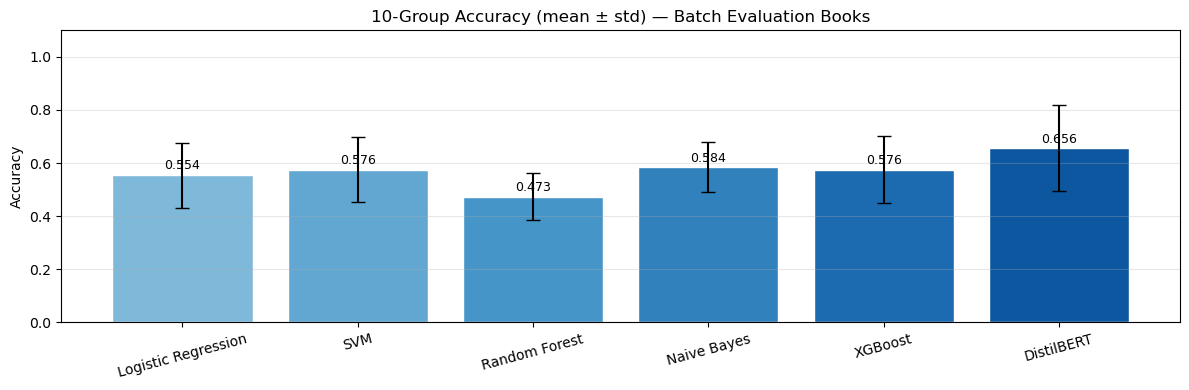

Saved: images/batch_eval_kgroup_accuracy.png


In [20]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
fold_results = {col: [] for col in MODEL_COLS}

for _, test_idx in kfold.split(preds_df, preds_df['true']):
    fold = preds_df.iloc[test_idx]
    for col in MODEL_COLS:
        fold_results[col].append(accuracy_score(fold['true'], fold[col]))

print(f"{'Model':25}  mean ± std  (10 book-level folds)")
for col, name in MODEL_COLS.items():
    scores = np.array(fold_results[col])
    print(f"  {name:25}  {scores.mean():.4f} ± {scores.std():.4f}")

names  = list(MODEL_COLS.values())
means  = [np.mean(fold_results[c]) for c in MODEL_COLS]
stds   = [np.std(fold_results[c])  for c in MODEL_COLS]

colors = plt.cm.Blues(np.linspace(0.45, 0.85, len(names)))
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(names, means, yerr=stds, color=colors, edgecolor='white', capsize=5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_title('10-Group Accuracy (mean ± std) — Batch Evaluation Books', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/batch_eval_kgroup_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/batch_eval_kgroup_accuracy.png')

## Confusion Matrices
Seaborn heatmaps for all six models in a 2×3 grid, plus a per-genre grouped accuracy chart.

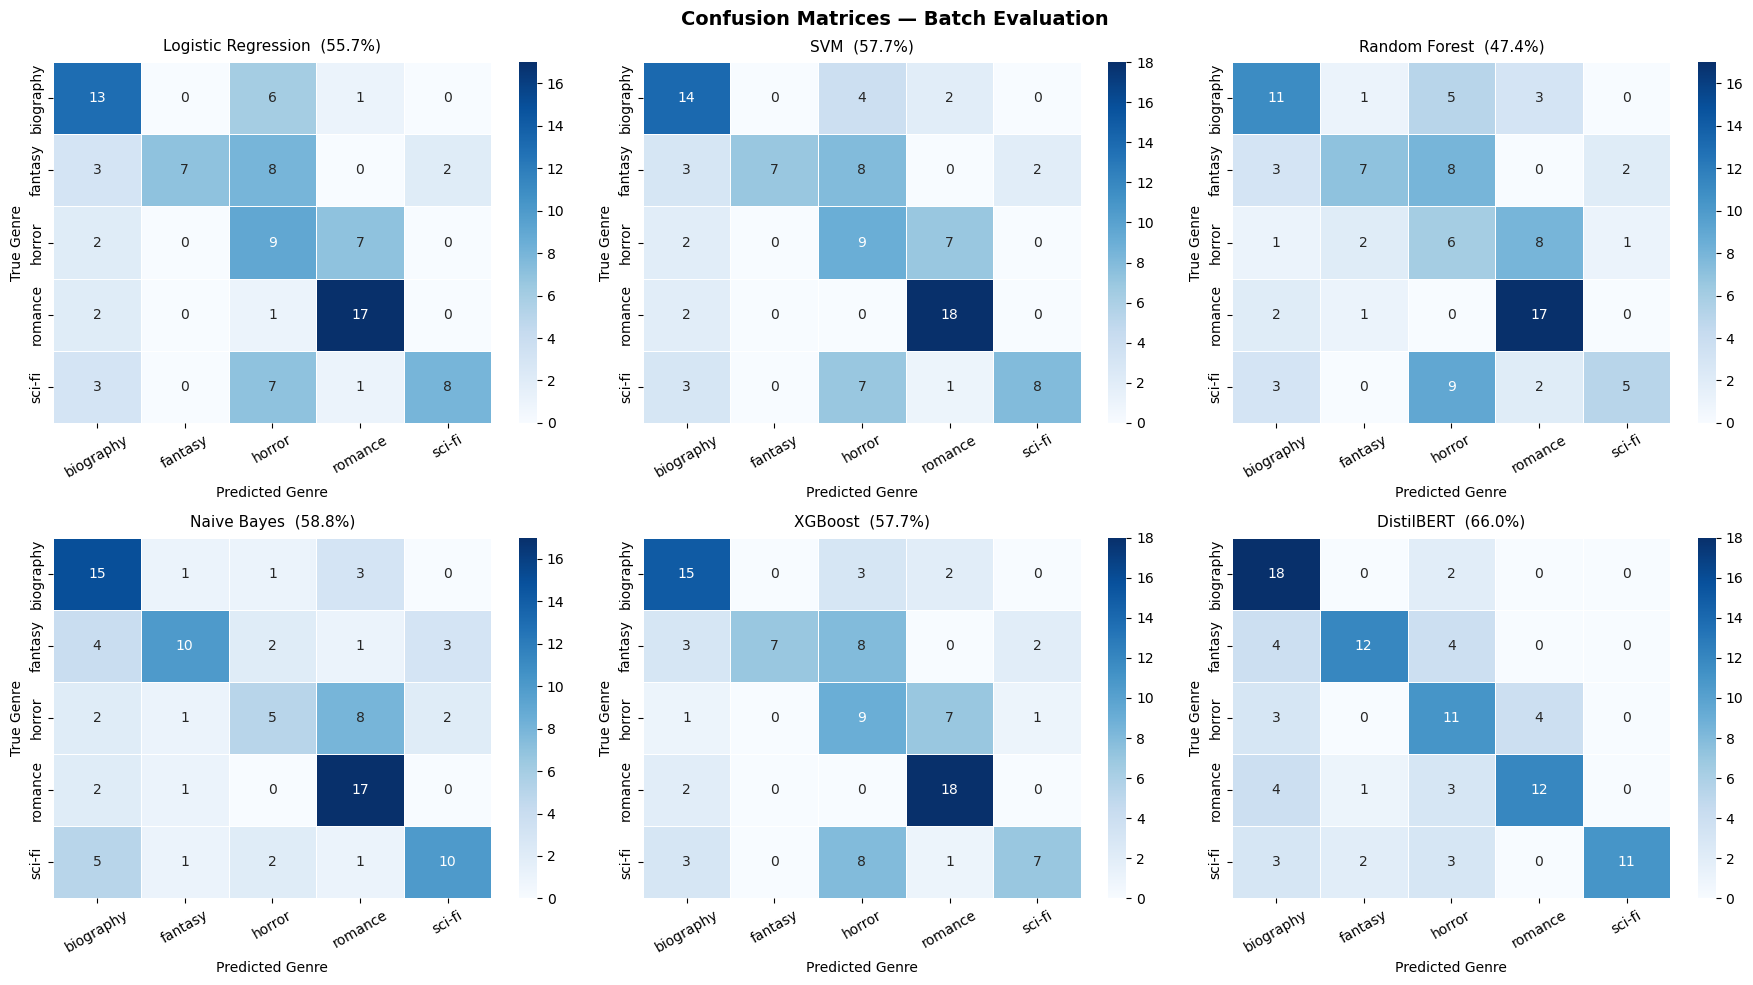

Saved: images/batch_eval_confusion_matrix.png


C:\Users\rakan\AppData\Local\Temp\ipykernel_15616\3141346597.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_genre = preds_df.groupby('true').apply(
C:\Users\rakan\AppData\Local\Temp\ipykernel_15616\3141346597.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_genre = preds_df.groupby('true').apply(
C:\Users\rakan\AppData\Local\Temp\ipykernel_15616\3141346597.py:27: FutureWarning: DataFrameGroupBy.appl

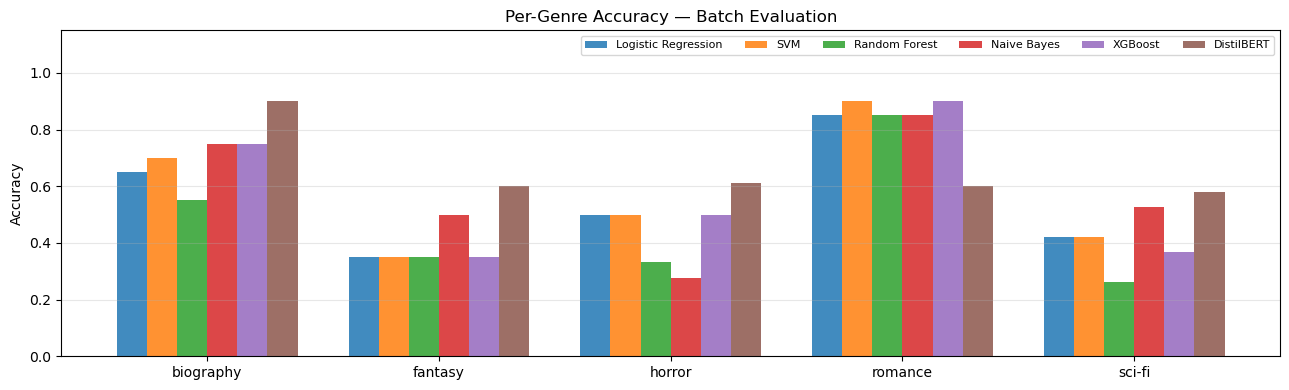

Saved: images/batch_eval_per_genre_accuracy.png


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (col, name) in zip(axes_flat, MODEL_COLS.items()):
    cm = confusion_matrix(preds_df['true'], preds_df[col], labels=GENRES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES,
                linewidths=0.5, ax=ax)
    acc = accuracy_score(preds_df['true'], preds_df[col])
    ax.set_title(f'{name}  ({acc:.1%})', fontsize=11, pad=8)
    ax.set_xlabel('Predicted Genre')
    ax.set_ylabel('True Genre')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Confusion Matrices — Batch Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/batch_eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/batch_eval_confusion_matrix.png')

# Per-genre accuracy grouped bar chart
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
x, width = np.arange(len(GENRES)), 0.13

fig, ax = plt.subplots(figsize=(13, 4))
for i, (col, name) in enumerate(MODEL_COLS.items()):
    per_genre = preds_df.groupby('true').apply(
        lambda g: (g[col] == g['true']).mean()
    ).reindex(GENRES)
    ax.bar(x + (i - 2.5) * width, per_genre, width,
           label=name, color=model_colors[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(GENRES)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Genre Accuracy — Batch Evaluation')
ax.legend(fontsize=8, ncol=6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/batch_eval_per_genre_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/batch_eval_per_genre_accuracy.png')

## Error Analysis
Shows which books were misclassified per model and the genre they were incorrectly assigned to.
Useful for understanding which genres are most confused with each other at the book level.

In [22]:
print("=== ERROR ANALYSIS — MISCLASSIFIED BOOKS ===\n")
for col, name in MODEL_COLS.items():
    errors = preds_df[preds_df['true'] != preds_df[col]]
    print(f"{'='*60}")
    print(f"  {name} — {len(errors)} / {len(preds_df)} books misclassified")
    print(f"{'='*60}")
    if errors.empty:
        print("  No misclassifications.\n")
        continue
    pair_counts = errors.groupby(['true', col]).size().rename('count')
    print("  Confusion pairs:")
    print(pair_counts.to_string())
    print("\n  Misclassified books:")
    for _, row in errors.iterrows():
        print(f"    [{row['true']}] → [{row[col]}]:  {row['title']}")
    print()

=== ERROR ANALYSIS — MISCLASSIFIED BOOKS ===

  Logistic Regression — 43 / 97 books misclassified
  Confusion pairs:
true       lr       
biography  horror       6
           romance      1
fantasy    biography    3
           horror       8
           sci-fi       2
horror     biography    2
           romance      7
romance    biography    2
           horror       1
sci-fi     biography    3
           horror       7
           romance      1

  Misclassified books:
    [biography] → [horror]:  Autobiography of Benvenuto Cellini
    [biography] → [romance]:  An Autobiography - Anthony Trollope
    [biography] → [horror]:  Theodore Roosevelt An Autobiography
    [biography] → [horror]:  Narrative of Sojourner Truth
    [biography] → [horror]:  Confessions of Saint Augustine
    [biography] → [horror]:  My Bondage and My Freedom - Frederick Douglass
    [biography] → [horror]:  Narrative of William Wells Brown
    [fantasy] → [biography]:  The Princess and the Goblin - MacDonald
    [

## Vocabulary Coverage
How much of the 1,109-word training vocabulary do the unseen test books actually contain — and does it matter?

The vocabulary was built from 25 training books (5 per genre). When an unseen book uses very different words, the TF-IDF models see mostly zeros and have little to work with.

- **Left chart** — per-genre distribution of vocabulary coverage across books. A genre with consistently low coverage signals that its training books used a narrow or unusual word set that may not generalise.
- **Right chart** — scatter of vocabulary coverage vs model agreement (fraction of 6 models that predicted the genre correctly). The dashed trend line shows whether higher coverage correlates with better predictions.

*DistilBERT is included in the model-agreement fraction but is less affected by vocabulary coverage since it uses contextual token embeddings rather than fixed TF-IDF features.*

Processing biography... 20 books
Processing fantasy... 20 books
Processing horror... 18 books
Processing romance... 20 books
Processing sci-fi... 19 books

Analysis data collected: 97 books


C:\Users\rakan\AppData\Local\Temp\ipykernel_15616\1442572273.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='genre', y='vocab_coverage',


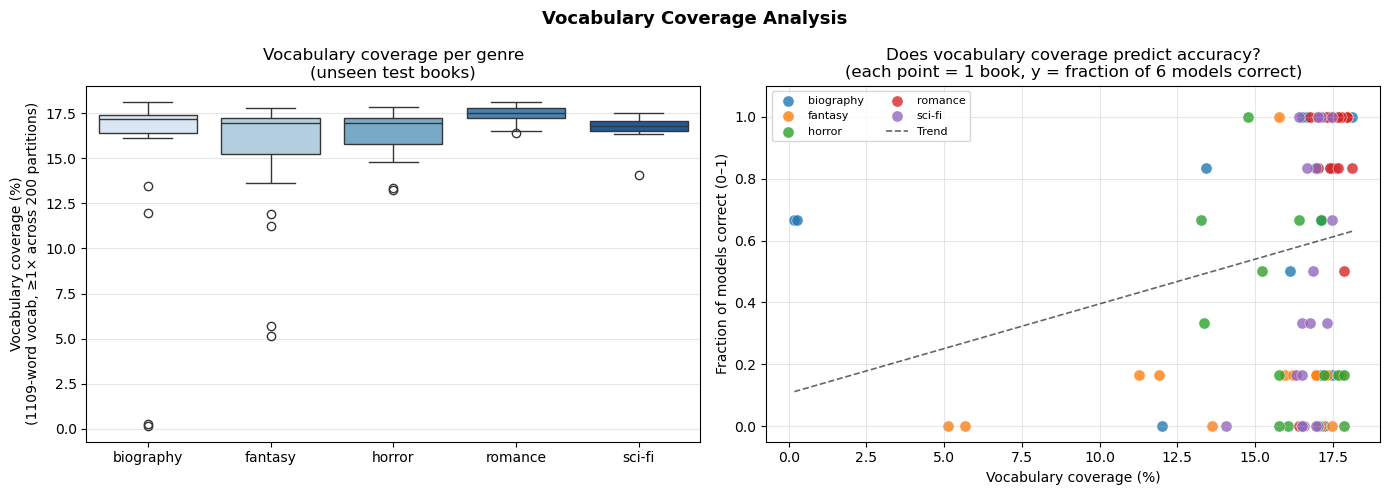

Saved: images/batch_eval_vocab_coverage.png


In [23]:
# ── Data collection: vocabulary coverage + model confidence (one pass per book) ─
# Uses the same clean_and_partition helper defined above.
# DistilBERT inference runs in batches of 32 on GPU; expect ~30–60 s total.
vocab_size    = len(vec.vocabulary_)
analysis_rows = []

for genre, books in downloaded.items():
    print(f'Processing {genre}...', end=' ', flush=True)
    count = 0
    for path, title in books:
        parts = clean_and_partition(path)
        if parts is None:
            continue
        X = vec.transform(parts)

        # Vocabulary coverage: fraction of the 1,109-word vocab seen ≥1× in this book
        n_covered = int(np.asarray((X > 0).sum(axis=0) > 0).flatten().sum())

        # Model confidence: mean max-probability across 200 partitions per model
        analysis_rows.append({
            'title':          title,
            'genre':          genre,
            'vocab_coverage': n_covered / vocab_size * 100,
            'conf_lr':        lr.predict_proba(X).max(axis=1).mean(),
            'conf_rf':        rf.predict_proba(X).max(axis=1).mean(),
            'conf_nb':        nb.predict_proba(X).max(axis=1).mean(),
            'conf_xgb':       xgb_clf.predict_proba(X).max(axis=1).mean(),
            'conf_bert':      bert_clf.predict_proba(parts).max(axis=1).mean(),
        })
        count += 1
    print(f'{count} books')

# Merge book-level predictions from preds_df so we can compute correct/incorrect
analysis_df = pd.DataFrame(analysis_rows).merge(
    preds_df[['title', 'lr', 'svm', 'rf', 'nb', 'xgb', 'bert']],
    on='title', how='left',
)
# Fraction of all 6 models that got this book right
for col in ['lr', 'svm', 'rf', 'nb', 'xgb', 'bert']:
    analysis_df[f'{col}_correct'] = (analysis_df[col] == analysis_df['genre']).astype(int)
analysis_df['model_agreement'] = analysis_df[
    ['lr_correct', 'svm_correct', 'rf_correct', 'nb_correct', 'xgb_correct', 'bert_correct']
].mean(axis=1)
print(f'\nAnalysis data collected: {len(analysis_df)} books')

# ── Vocabulary Coverage plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coverage distribution per genre
sns.boxplot(data=analysis_df, x='genre', y='vocab_coverage',
            palette='Blues', order=GENRES, ax=axes[0])
axes[0].set_ylabel(f'Vocabulary coverage (%)\n({vocab_size}-word vocab, ≥1× across 200 partitions)')
axes[0].set_xlabel('')
axes[0].set_title('Vocabulary coverage per genre\n(unseen test books)')
axes[0].grid(axis='y', alpha=0.3)

# Right: scatter — does vocabulary coverage predict how many models get it right?
genre_colors = dict(zip(GENRES, ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']))
for genre in GENRES:
    sub = analysis_df[analysis_df['genre'] == genre]
    axes[1].scatter(sub['vocab_coverage'], sub['model_agreement'],
                    color=genre_colors[genre], label=genre,
                    s=65, alpha=0.8, edgecolors='white', linewidths=0.4)
z    = np.polyfit(analysis_df['vocab_coverage'], analysis_df['model_agreement'], 1)
xfit = np.linspace(analysis_df['vocab_coverage'].min(), analysis_df['vocab_coverage'].max(), 100)
axes[1].plot(xfit, np.poly1d(z)(xfit), 'k--', linewidth=1.2, alpha=0.6, label='Trend')
axes[1].set_xlabel('Vocabulary coverage (%)')
axes[1].set_ylabel('Fraction of models correct (0–1)')
axes[1].set_title('Does vocabulary coverage predict accuracy?\n(each point = 1 book, y = fraction of 6 models correct)')
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(alpha=0.3)

fig.suptitle('Vocabulary Coverage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/batch_eval_vocab_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/batch_eval_vocab_coverage.png')

## Inter-Genre Vocabulary Overlap
A book can have high vocabulary coverage yet still be misclassified if the words it matches are shared across many genres and therefore provide no discriminative signal.

- **Left heatmap** — Jaccard similarity between each pair of genres' vocabulary sets, with the raw shared word count in brackets. Genre pairs with high overlap here will reliably appear as confusion pairs in the confusion matrices above — this is a structural property of the vocabulary, not a model failure.
- **Right chart** — word discriminability across the 1,109-word vocabulary. Words that appear in only one genre's training partitions (exclusive) are strong signals. Words shared across all five genres contribute nothing to genre separation for TF-IDF models.

Training partitions are reloaded from `TestingData/partitions.csv` to compute the word sets — no extra download needed.

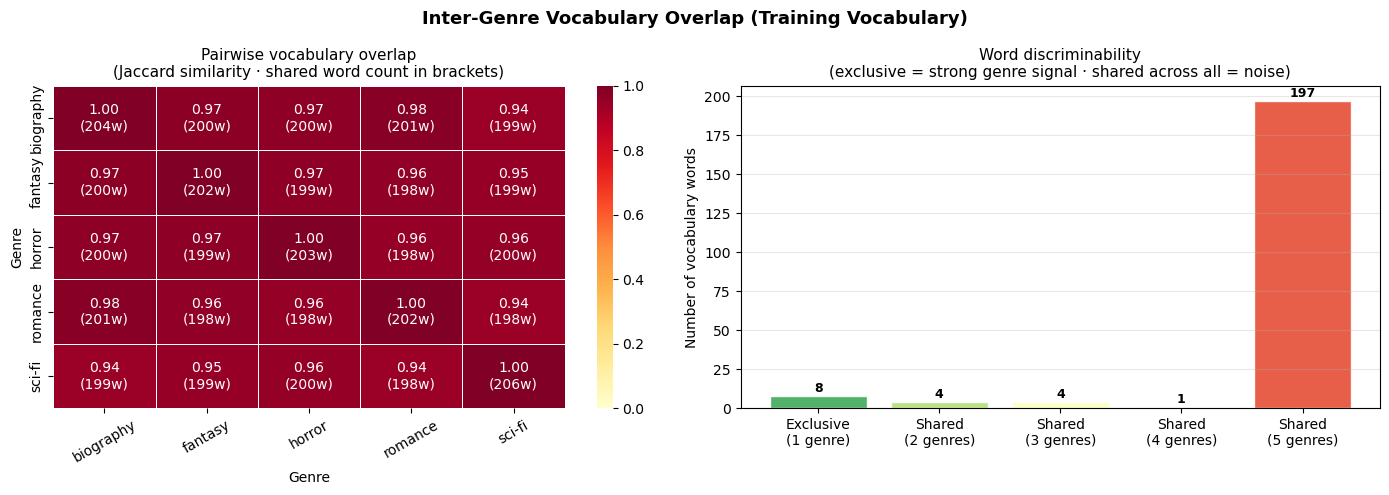

Saved: images/batch_eval_vocab_genre_overlap.png

Genre vocabulary sizes (training):
  biography   :  204 / 1109 words covered
  fantasy     :  202 / 1109 words covered
  horror      :  203 / 1109 words covered
  romance     :  202 / 1109 words covered
  sci-fi      :  206 / 1109 words covered

Word discriminability breakdown:
     8 words exclusive to 1 genre (0.7% of vocabulary)
     4 words shared across 2 genres (0.4% of vocabulary)
     4 words shared across 3 genres (0.4% of vocabulary)
     1 words shared across 4 genres (0.1% of vocabulary)
   197 words shared across 5 genres (17.8% of vocabulary)

  Words in ALL 5 genres (197): across, air, also, always, among, another, answered, asked, away, back, beautiful, began, better, black, british, called, came, cannot, captain, child, children, come, could, count, country, cried, day, days, dead, dear, death, done, door, empire, england, enough, even, ever, every, eyes, face, far, father, fear, feet, fell, felt, find, first, following

In [24]:
# ── Inter-Genre Vocabulary Overlap ────────────────────────────────────────────
# Reconstruct ordered vocabulary list from the fitted vectorizer (index → word)
vocab_list = sorted(vec.vocabulary_, key=lambda w: vec.vocabulary_[w])

# Load training partitions to compute which words each genre actually uses
_parts_df = pd.read_csv('TestingData/partitions.csv')
_X_tr     = vec.transform(_parts_df['text'].tolist())
_y_tr     = _parts_df['genre'].tolist()

genre_word_sets = {}
for genre in GENRES:
    col_sums = np.asarray(_X_tr[np.array(_y_tr) == genre].sum(axis=0)).flatten()
    genre_word_sets[genre] = set(np.where(col_sums > 0)[0].tolist())

# Pairwise absolute overlap count and Jaccard similarity
n = len(GENRES)
overlap_count   = np.zeros((n, n), dtype=int)
overlap_jaccard = np.zeros((n, n))
for i, g1 in enumerate(GENRES):
    for j, g2 in enumerate(GENRES):
        inter = len(genre_word_sets[g1] & genre_word_sets[g2])
        union = len(genre_word_sets[g1] | genre_word_sets[g2])
        overlap_count[i, j]   = inter
        overlap_jaccard[i, j] = inter / union if union else 0.0

# Word discriminability: how many genres each vocabulary word appears in
word_genre_count = np.zeros(vocab_size, dtype=int)
for ws in genre_word_sets.values():
    for idx in ws:
        word_genre_count[idx] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Jaccard heatmap annotated with Jaccard + raw count
annot = np.array([[f'{overlap_jaccard[i,j]:.2f}\n({overlap_count[i,j]}w)'
                   for j in range(n)] for i in range(n)])
sns.heatmap(overlap_jaccard, annot=annot, fmt='', cmap='YlOrRd',
            xticklabels=GENRES, yticklabels=GENRES,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Pairwise vocabulary overlap\n(Jaccard similarity · shared word count in brackets)', fontsize=11)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Genre')
axes[0].tick_params(axis='x', rotation=30)

# Right: word discriminability histogram
disc = [(k, int((word_genre_count == k).sum())) for k in range(1, n + 1)]
disc = [(k, c) for k, c in disc if c > 0]
ks, cs = zip(*disc)
bar_colors = plt.cm.RdYlGn(np.linspace(0.85, 0.15, len(ks)))
bars = axes[1].bar(range(len(ks)), cs, color=bar_colors, edgecolor='white', alpha=0.9)
for bar, c in zip(bars, cs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(c), ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(ks)))
axes[1].set_xticklabels(['Exclusive\n(1 genre)' if k == 1 else f'Shared\n({k} genres)' for k in ks])
axes[1].set_ylabel('Number of vocabulary words')
axes[1].set_title('Word discriminability\n(exclusive = strong genre signal · shared across all = noise)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Inter-Genre Vocabulary Overlap (Training Vocabulary)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/batch_eval_vocab_genre_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/batch_eval_vocab_genre_overlap.png')

print(f"\nGenre vocabulary sizes (training):")
for g in GENRES:
    print(f"  {g:12}: {len(genre_word_sets[g]):4d} / {vocab_size} words covered")

print(f"\nWord discriminability breakdown:")
for k, c in disc:
    label = "exclusive to 1 genre" if k == 1 else f"shared across {k} genres"
    print(f"  {c:4d} words {label} ({c/vocab_size:.1%} of vocabulary)")

words_in_all = [vocab_list[i] for i, cnt in enumerate(word_genre_count) if cnt == n]
if words_in_all:
    print(f"\n  Words in ALL {n} genres ({len(words_in_all)}): {', '.join(words_in_all)}")

## Model Confidence
When a model classifies an unseen book, how confident is it — and does that confidence differ between books it gets right vs wrong?

Confidence is measured as the mean max-probability across all 200 partitions for a book, then averaged by outcome (correct / incorrect). Unlike the Genre Classifier section (partition-level), everything here is at the book level.

- **Left chart** — mean confidence for correctly vs incorrectly classified books. A wide gap signals the model is genuinely uncertain on hard books; a narrow gap means it predicts with similar conviction regardless of whether it is right.
- **Right chart** — full distribution of book-level mean confidence per model, as a violin plot.

*SVM excluded — LinearSVC has no calibrated probabilities.*

C:\Users\rakan\AppData\Local\Temp\ipykernel_15616\2340860170.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=conf_plot_df, x='Model', y='Mean Max Probability', ax=axes[1],


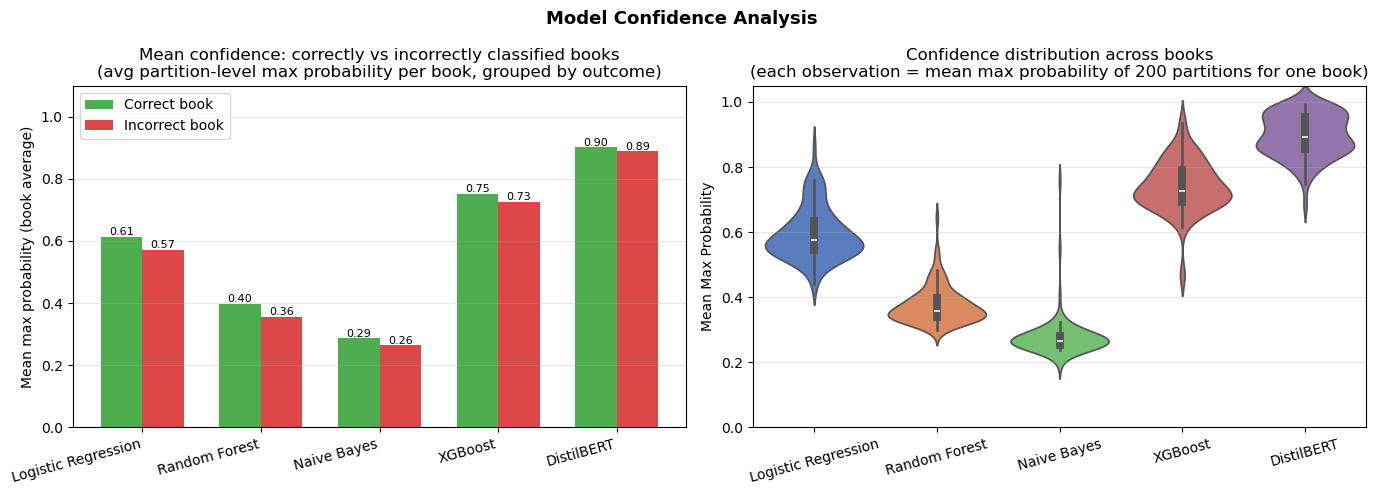

Saved: images/batch_eval_model_confidence.png


In [25]:
# ── Model Confidence Analysis ────────────────────────────────────────────────
# SVM excluded — LinearSVC does not support predict_proba
conf_meta = {
    'conf_lr':   ('Logistic Regression', 'lr'),
    'conf_rf':   ('Random Forest',       'rf'),
    'conf_nb':   ('Naive Bayes',         'nb'),
    'conf_xgb':  ('XGBoost',             'xgb'),
    'conf_bert': ('DistilBERT',          'bert'),
}

model_labels   = [v[0] for v in conf_meta.values()]
mean_conf_corr   = []
mean_conf_incorr = []
conf_rows        = []

for conf_col, (name, pred_col) in conf_meta.items():
    correct_mask   = analysis_df[pred_col] == analysis_df['genre']
    incorrect_mask = ~correct_mask
    mean_conf_corr.append(analysis_df.loc[correct_mask,   conf_col].mean())
    mean_conf_incorr.append(analysis_df.loc[incorrect_mask, conf_col].mean()
                            if incorrect_mask.any() else np.nan)
    for v in analysis_df[conf_col]:
        conf_rows.append({'Model': name, 'Mean Max Probability': v})

conf_plot_df = pd.DataFrame(conf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean confidence for correctly vs incorrectly classified books
x, width = np.arange(len(model_labels)), 0.35
ax = axes[0]
bars_c  = ax.bar(x - width/2, mean_conf_corr,   width, label='Correct book',   color='#2ca02c', alpha=0.85)
bars_ic = ax.bar(x + width/2, mean_conf_incorr, width, label='Incorrect book', color='#d62728', alpha=0.85)
for bar, v in zip(bars_c, mean_conf_corr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.2f}', ha='center', fontsize=8)
for bar, v in zip(bars_ic, mean_conf_incorr):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha='right')
ax.set_ylabel('Mean max probability (book average)')
ax.set_ylim(0, 1.1)
ax.set_title('Mean confidence: correctly vs incorrectly classified books\n(avg partition-level max probability per book, grouped by outcome)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: confidence distribution per model (violin)
sns.violinplot(data=conf_plot_df, x='Model', y='Mean Max Probability', ax=axes[1],
               palette='muted', inner='box')
axes[1].set_title('Confidence distribution across books\n(each observation = mean max probability of 200 partitions for one book)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/batch_eval_model_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/batch_eval_model_confidence.png')

## Per-Book Results
Full breakdown of every book's prediction vs. true genre. Green = correct, red = wrong.

In [26]:
rename_map = {'title': 'Book', 'true': 'True Genre',
              'lr': 'LR', 'svm': 'SVM', 'rf': 'RF', 'nb': 'NB',
              'xgb': 'XGBoost', 'bert': 'DistilBERT'}
detail_df = preds_df.rename(columns=rename_map).copy()
for col in ['LR', 'SVM', 'RF', 'NB', 'XGBoost', 'DistilBERT']:
    detail_df[f'{col} ✓'] = detail_df[col] == detail_df['True Genre']
cols = ['Book', 'True Genre',
        'LR', 'LR ✓', 'SVM', 'SVM ✓', 'RF', 'RF ✓', 'NB', 'NB ✓',
        'XGBoost', 'XGBoost ✓', 'DistilBERT', 'DistilBERT ✓']
detail_df = detail_df[cols].sort_values(['True Genre', 'Book']).reset_index(drop=True)

check_cols = [c for c in detail_df.columns if c.endswith(' ✓')]
display(
    detail_df.style.apply(
        lambda col: ['background: #d4edda' if v else 'background: #f8d7da' for v in col]
        if col.name in check_cols else ['' for _ in col],
        axis=0,
    )
)

,Book,True Genre,LR,LR ✓,SVM,SVM ✓,RF,RF ✓,NB,NB ✓,XGBoost,XGBoost ✓,DistilBERT,DistilBERT ✓
0,An Autobiography - Anthony Trollope,biography,romance,False,romance,False,romance,False,romance,False,romance,False,biography,True
1,Autobiography - John Stuart Mill,biography,biography,True,biography,True,biography,True,biography,True,biography,True,biography,True
2,Autobiography of Benvenuto Cellini,biography,horror,False,horror,False,horror,False,fantasy,False,horror,False,horror,False
3,Confessions - Jean-Jacques Rousseau,biography,biography,True,biography,True,biography,True,biography,True,biography,True,biography,True
4,Confessions of Saint Augustine,biography,horror,False,biography,True,horror,False,biography,True,horror,False,biography,True
5,Diary of Samuel Pepys Vol 1,biography,biography,True,biography,True,biography,True,biography,True,biography,True,biography,True
6,Geronimos Story of His Life,biography,biography,True,biography,True,biography,True,biography,True,biography,True,biography,True
7,Grace Abounding - John Bunyan,biography,biography,True,biography,True,horror,False,biography,True,biography,True,biography,True
8,Incidents in the Life of a Slave Girl,biography,biography,True,biography,True,romance,False,romance,False,biography,True,biography,True
9,My Bondage and My Freedom - Frederick Douglass,biography,horror,False,romance,False,romance,False,romance,False,romance,False,biography,True
